
## Preliminaries


1. Thanks for the feedback!
2. Some of you are concerned about the pace of the course.
3. Textbooks/reading material etc.

   1. You can go through the [Python tutorial](https://docs.python.org/3/tutorial/index.html)
   2. Then go through the [Python Data Science Handbook](https://jakevdp.github.io/PythonDataScienceHandbook/)


First poll to check your typing speed!


We first start with the standard imports.


# More Python and plotting

Let us now look at plotting data points that are not generated from
analytical functions but may be from an experiment or measurement.

We first start with the standard imports.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


Now consider the following data points that we want to plot for a
measurement of some vehicle versus time.

| Time     | 0.0 | 1.0 | 2.0  | 3.0  |
|----------|-----|-----|------|------|
| Distance | 5.0 | 9.0 | 13.0 | 17.0 |

How do we plot it?  Try the following:

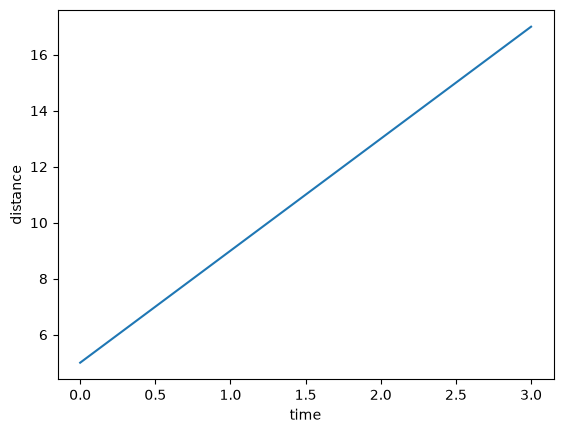

In [2]:
time = [0.0, 1.0, 2, 3]
distance = [5.0, 9.0, 13, 17]
plt.plot(time, distance)
plt.xlabel('time')
plt.ylabel('distance');

What if we didn't want the lines but want to see just the points?

You should have already seen this in the last class material!

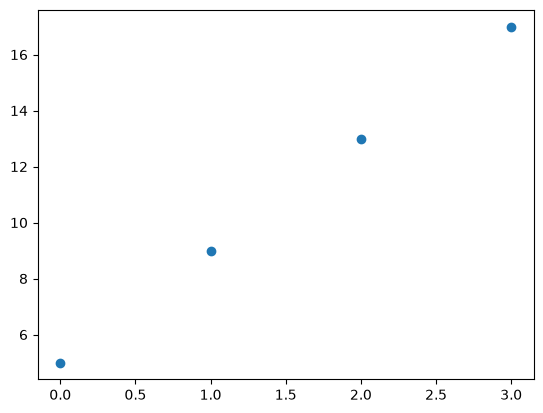

In [3]:
plt.plot(time, distance, 'o');

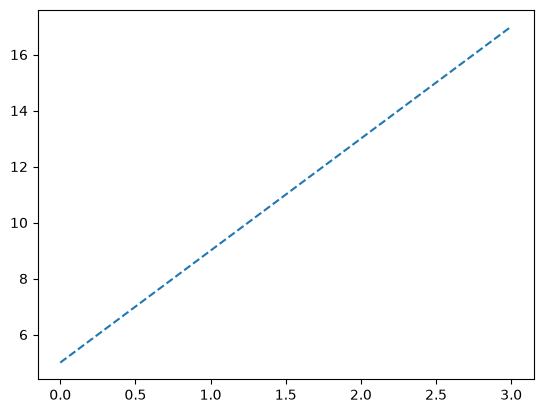

In [4]:
# This uses a dashed line.
plt.plot(time, distance, '--');

So the variable `time` and `distance` you see here is what is called a Python `list`.

In [5]:
print(type(time))
type(distance)

<class 'list'>


list


Lists are a powerful builtin Python data type. Let us learn a bit more about
them.

### Initialization and access

In [6]:
# An empty list
e = []

# A non-empty list
p = [2, 3, 5, 7]

In [7]:
type(p)

list

In [8]:
# Indexing starts at 0
p[0]

2

In [9]:
p[1]

3

In [10]:
p[0] + p[1] + p[-1]

12


### List Slicing

Slicing always produces a list. The general syntax is:

`list[initial:final:step]`

initial/final are indices and the `final` is not included

Negative indices start from the end (-1 is the last element).

Examples make it easier.

In [11]:
p[1:3]

[3, 5]

In [12]:
p[0:-1]

[2, 3, 5]

In [13]:
p[1:]

[3, 5, 7]

In [14]:
p[:2]

[2, 3]

In [15]:
p[0:4:2]

[2, 5]

In [16]:
p[0::2]

[2, 5]

In [17]:
p[::2]

[2, 5]

In [18]:
p[::3]

[2, 7]

In [19]:
p[::-1]

[7, 5, 3, 2]


### Quick quiz

What is the output of the following?

In [20]:
p[1::2]

[3, 7]

In [21]:
p[1:-1:2]

[3]


The builtin `len` function tells us the length of a list.


In [22]:
len(p)

4


### List operations

Lists support other operations like addition and also have what are
called **methods**.

For example:

In [23]:
b = [11, 13, 17]
c = p + b
c

[2, 3, 5, 7, 11, 13, 17]

In [24]:
# Do you think this will work?
b * 2

[11, 13, 17, 11, 13, 17]

In [25]:
# Do you expect that this will work?
b * 2.5

TypeError: can't multiply sequence by non-int of type 'float'


- `+` and `*` here are "operators"

Let us look at "methods" next.

In [26]:
p.append(11)
p

[2, 3, 5, 7, 11]

Does `c` change now that `p` has a new element?



In [27]:
c

[2, 3, 5, 7, 11, 13, 17]


- Note the use of `p.append`
- `p` is a list **object**
- `p.append` is called a **method**, it is a function that applies to the list
- In this case the function appends a new value.

### Quick exercise

Read the documentation for the append method on your notebook.

In [28]:
help(p.append)

Help on built-in function append:

append(object, /) method of builtins.list instance
    Append object to the end of the list.




- Also do `p.<TAB>` to find other list methods!
- Note that lists need not only contain elements of a single type.

In [29]:
mixer = [1, 1.0, 'string', [1, 2, 3]]

In [30]:
# The type of each element is different.
print(type(mixer[0]))
type(mixer[1])

<class 'int'>


float


We now have a basic understanding of how we can use lists. Let us look at
some "real" data.

We look at a simple pendulum experiment:

| L | 0.2 | 0.3  | 0.4  | 0.5  | 0.6  | 0.7  | 0.8  |
|---|-----|------|------|------|------|------|------|
| T | 0.9 | 1.19 | 1.30 | 1.47 | 1.58 | 1.77 | 1.83 |

Let us do some analysis with this data. First put this into a list.

For those of you who recall your basic physics, we expect that $L \propto T^2$
is a straight line.

In [31]:
L = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
t = [0.90, 1.19, 1.30, 1.47, 1.58, 1.77, 1.83]

In [32]:
# Making sure both have the same number of elements
print(len(L), len(t))

7 7



In order to plot this, we first need to get $t^2$ from the time values.
Using `t*t` will not work, let us try

In [33]:
t*t

TypeError: can't multiply sequence by non-int of type 'list'


We can use a `for` loop to do this.

Here is a simple example

In [34]:
for time in t:
    print(time*time)

0.81
1.4161
1.6900000000000002
2.1609
2.4964000000000004
3.1329000000000002
3.3489000000000004


In [35]:
# Here is a longer example which illustrates a bit more.
# Run this and then we will walk through the lines of code.
for time in t:
    tsq = time*time
    print(time, tsq)
print("Done")

0.9 0.81
1.19 1.4161
1.3 1.6900000000000002
1.47 2.1609
1.58 2.4964000000000004
1.77 3.1329000000000002
1.83 3.3489000000000004
Done



- Recall that our goal is to be able to plot $L$ vs $T^2$.
- How do we store these values so we can use plot?
- We can create an empty list and add elements into the list.

Here is an approach

In [36]:
tsq = []
for time in t:
    tsq.append(time*time)

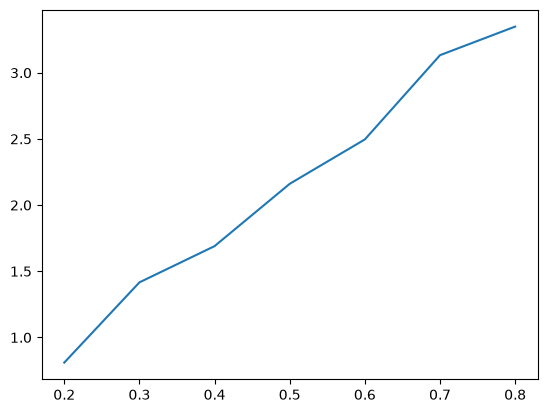

In [37]:
# Now we can plot this!
plt.plot(L, tsq)

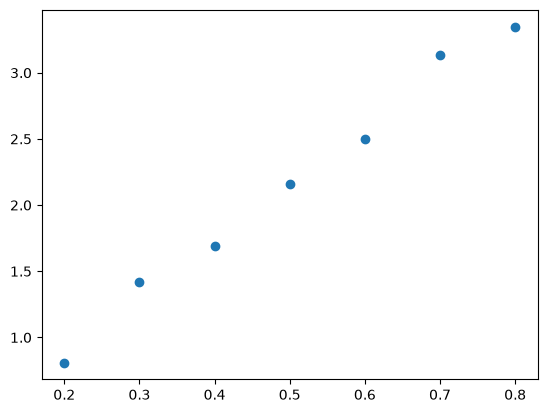

In [38]:
# Or just plot the points alone.
plt.plot(L, tsq, 'o')

### Pop quiz

What happens to if we now write this code:

In [39]:
for time in t:
    tsq.append(time*time)

In [40]:
len(tsq)

14

Beware of things like this!

## Exercise

Consider the list `x = [1.0, 2.0, 3.0]`. Write code to compute twice of each value
and store the result in a new list as variable `y`.

In [41]:
x = [1.0, 2.0, 3.0]

In [43]:
y=[]
for i in x:
    y.append(i*2)
print(y)

[2.0, 4.0, 6.0]



## A small digression: the `range` builtin

- Let us say we do not have a list but want to iterate or repeat something
- Let us say you want to iterate not over the elements but over the indices
  of the list/array?

Solving these things is much easier with the introduction of the `range`
builtin function. Try this:

In [44]:
for i in range(4):
    print(i)

0
1
2
3


In [45]:
for i in range(4, 8):
    print(i)

4
5
6
7


In [46]:
for i in range(0, 8, 2):
    print(i)

0
2
4
6


As you can see the syntax is either
- `range(stop)`
- or `range(start, stop, step)`
- Note that the `stop` value is not included. (we saw this earlier too?)

- Note that `range` does not actually create a list.

In [47]:
range(5)

range(0, 5)

In [48]:
range(0, 5, 2)

range(0, 5, 2)

If you want a list, you can use the `list` to create one.

Note that `list` takes any **sequence** (like tuple, array, string etc.) and converts it into a list.


In [49]:
list(range(5))

[0, 1, 2, 3, 4]

## Exercise

- Create a list which has the square of the integers from 1-9.
- Your code should produce [1, 4, 9, 16, 25, 36, 49, 64, 81]

In [51]:
square_of_integers=[]
for i in range(1,10):
    square_of_integers.append(i*i)
print(square_of_integers)

[1, 4, 9, 16, 25, 36, 49, 64, 81]


## Exercise

Given the list, `distance` that we had earlier, for each element of the list
print its index and value.

In [53]:
for i in range (0,len(distance)):
    print("Index : " ,i,"Distance : " ,distance[i])

Index :  0 Distance :  5.0
Index :  1 Distance :  9.0
Index :  2 Distance :  13
Index :  3 Distance :  17



## Another digression: Quick introduction to booleans and conditionals

Conditionals are very easy to write in Python.

As usual we will look at examples to learn this also. :)

In [54]:
v = -21
v < 0

True

In [55]:
v > 0

False

There is are builtin `True` and `False` values

In [56]:
# Equality requires 2 equal-to signs, recall that one `=` is for variable
# assignement.
v == 0

False

In [57]:
# Not equal to.
v != 0

True

In [58]:
v >= 0

False

In [59]:
v <= -21

True

You can combine the boolean expressions with `or`, `and` and `not`.

In [60]:
y = 1

# Always good to use brackets so the intent is very clear and easy to read.
(v > 0) or (y > 0)

True

In [61]:
(v > 0) and (y > 0)

False

In [62]:
not (v >= 0)

True

In [63]:
not True

False

In [64]:
(v > 0) and not (y > 0)

False


We can now quickly look at conditionals which are super easy to write in
Python.

Here we go again with more examples:

In [65]:
if v < 0:
    print("Negative value")
elif v > 0:
    print("Positive")
else:
    print("ZERO!")

Negative value



Note that the `elif` and `else` are optional

In [66]:
temp = 100
if temp < 0:
    print("OMG! Your calculation is garbage! Negative temperature makes no sense")


## Exercise

- Print the first 10 odd numbers.
- Use a conditional or I will increase 10 to 1000!
- Generate a list of values with the square of the first 10 odd numbers.


In [67]:
# Hint
v = 22
# % is the modulo operator
v % 2

0

In [68]:
21 % 2

1

In [71]:
for i in range(1, 20):
    if i%2 != 0:
        print(i)

1
3
5
7
9
11
13
15
17
19


In [72]:
for i in range(1, 20):
    if i%2 != 0:
        print(i*i)

1
9
25
49
81
121
169
225
289
361


## A bit more on loops

### Nested loops

- You can nest multiple loops.
- You can also mix conditionals and looping constructs for more complex loops.

Here is a simple example.

In [73]:
for i in range(3):
    for j in range(3):
        print(i, j)  # Notice the indentation.

0 0
0 1
0 2
1 0
1 1
1 2
2 0
2 1
2 2


Once again, the indentation defines the respective blocks.

You can certainly write longer blocks of code before the `for j` or within
the `for j` block.

### Using `break` and `continue` in loops

- You can use `break` to exit a loop

Here is a silly example just to show you how

In [74]:
for i in range(10):
    if i > 5:
        break
    print(i)

0
1
2
3
4
5



Note that the loop ends when the `break` is seen and nothing after it in the loop is executed.

With `continue`, the remainder of the code is skipped like so:

In [75]:
for i in range(5):
    if i % 2 == 1:
        continue
    print(i)

0
2
4



## Aside: getting input from a user

- Useful to get input from a user.
- This is handy on the yaksh interface when you are given a problem. We will
  usually supply some input and test your code.

Try this

In [76]:
input()

'Hi'

In [77]:
input("Enter a number: ")  # Provides a prompt

'Hello123'


- Always returns a string
- Can convert to an int/float by casting.

For example:


In [79]:
x = int(input("Enter integer: "))
print(x, type(x))

12 <class 'int'>


In [80]:
x = float(input("Enter float: "))
print(x, type(x))

33.0 <class 'float'>



## Getting back to our pendulum problem!

Let us get back to our original data. We had the length, `L` and time period
`t`.  We wrote some code to get the square of the time values.

Now let us say we want to find the mean and standard deviation of these list
of values.

## Exercise

- Find the mean of the `L` values in the earlier array of 7 values.

In [81]:
print(sum(L)/len(L))

0.5



- Now find the mean of the `t` values

It is a bad idea to cut/copy code. So repeating the same code many times is
a very bad practice and you should actively watch yourself on this count.

- So how do we reduce this code copying and duplication?
- The answer is **abstraction** in the form of **functions**

Let us first write a simple function to square all elements of a list.

In [82]:
def sqr(lst):
    """Returns a list containing the square of the values of the given list."""
    result = []
    for x in lst:
        result.append(x*x)
    return result

Carefully note the syntax of the function
- `def` is a keyword, notice the `:` at the end of the line
- The triple quoted string below the `def` line is the "docstring" or documentation.
- The argument `lst` is a new function specific variable name
- The (optional) `return` keyword returns whatever value is given

In [83]:
tsq = sqr(t)
lsq = sqr(L)
# See the documentation of the sqr function

### Variable scope

- Variables inside function block are not available outside.
- If a name is not found in the function, Python looks outside the function.
- Objects passed into a function are passed by reference. **They are not copied!**

## Exercise

Write a function called mean which takes a list and returns the mean of the values.

In [ ]:
# Solution
def mean_of_list(lst):
    total=0
    for i in lst:
        total+=i
    return total/len(lst)

## Exercise

Write a function called sdev which takes a list and returns the standard
deviation of the values.

In [85]:
def sdev(lst):
    mean = mean_of_list(lst)
    variance = sum((x - mean) ** 2 for x in lst) / len(lst)
    return variance ** 0.5

### Function arguments

- Functions can take any number of arguments including none
- You can have default arguments and keyword arguments.
- Keyword arguments always come after positional arguments.

In [86]:
def silly(x):
    print(x)
    # Look ma, no return!

In [87]:
silly(42)

42


In [88]:
def hello():
    # Look ma, no arguments!
    print("hello world!")

In [89]:
def axpb(a, x, b):
    return a*x + b

axpb(2.5, 12, 1.65)

31.65

In [90]:
def one_two(x, y):
    return x+1, y+2

one_two(10, 20)

(11, 22)

In [91]:
u, v = one_two(10, 20)

### Default and keyword arguments


In [92]:
def greet(name, hi='Hello', repeat=1):
    for i in range(repeat):
        print(hi, name)

In [93]:
greet("Vinay")

Hello Vinay


In [94]:
greet("Vinay", "Namaste")

Namaste Vinay


In [95]:
greet("Vinay", "Namaste", 2)

Namaste Vinay
Namaste Vinay


In [96]:
greet("Vinay", hi="Namaste")

Namaste Vinay


In [97]:
greet("Vinay", repeat=3)

Hello Vinay
Hello Vinay
Hello Vinay


In [98]:
greet("Vinay", hi="Namaste", repeat=3)

Namaste Vinay
Namaste Vinay
Namaste Vinay


In [99]:
greet("Vinay", repeat=3 , hi="Namaste")

Namaste Vinay
Namaste Vinay
Namaste Vinay


In [100]:
# Can also do this, but then you have to name the first argument.
greet(hi="Namaste", name='X!')

Namaste X!



## Exercise

Write a function to find the mean squared error.


In [ ]:
# Solution

In [107]:
# My solution
def mse(x, y):
    diff = []
    for i in range(len(x)):
        diff.append(y[i] - x[i])
    sdiff = sqr(diff)
    return mean(sdiff)

In [108]:
mse(t,L)

0.8856

### Advanced
- The zip builtin is very convenient for things like the above.

Don't worry if you find this hard to follow.

In [102]:
def mse(x, y):
    diff = []
    for u, v in zip(x, y):
        diff.append(u - v)
    sdiff = sqr(diff)
    return mean(sdiff)

In [106]:
mse(t,L)

0.8856

In [105]:
# Simple zip example
zip(t, L)

## Timing a function in Jupyter

- Jupyter provides convenient magic functions. These start with `%`
- These are not available in Python but only in Jupyter/IPython consoles

An example.

In [109]:
n = 2**20
big = list(range(n))

In [110]:
%timeit sqr(big)

313 ms ± 14.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Enter Numpy!


In [111]:
big_np = np.array(big)

In [112]:
%timeit big_np*big_np

8.43 ms ± 909 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Other magic commands
- `%time`: one single measurement
- `%cd`
- `%run`
- `%pwd`: current directory.
etc.


- Numpy is very fast.
- It is also very convenient as we didn't need to write `sqr` and can
  directly multiply arrays.
- Lists are more general purpose but not meant for direct numerics


## Python scripts and modules

To create a Python script:
1. Create a text file with a `.py` extension
2. Put your functions and code inside.
3. You can then execute the file on a Python session.

Example script demo.

### Python modules

- You can import a script in the same directory.
- However there are constraints on the name of the file.
- The name of the file should be a valid variable name
- Can `import` this in another module.

### Valid Python module (or variable) names

- Should start with a letter
- Can use _ (underscore) and numbers
- No . allowed
- No spaces or special characters


### An example

```{python}
# script.py
def sqr(lst):
   ...
def mse(x, y):
   ...
```

Now in another script we can do:

```{python}
# other.py
import script

x = [1, 2, 3]
print(script.sqr(x))
```

### Other forms of import

- `import script`
- `import script as S`
- `from script import sqr`
- `from script import sqr, mse`


### Quiz

Which of these is a valid script?

1. 1_script.py
2. script_1.py
3. one11.py
4. one script.py
5. one,script;xxx.py
6. one.two.py

### A note for scripts that you import

- Importing from any script executes the whole code
- Need to guard against this
- The `__name__` special variable (double underscores are called "dunder")
   - The value of this is `'__main__'` when run as a script
   - The value is the name of the script when imported
- So use an `if __name__ == '__main__':` guard block

Let us look at a quick demo.



### Homework exercise

- Make a Python script from your earlier plot from last class.
- Make it so it can be executed from your installed anaconda shell.

## Summary
We learned about the following:

- Lists
  - Creating lists
  - Indexing, slicing
  - `len` builtin
  - List operators and methods
- For loops
  - Basic iteration
  - `range` builtin
- Booleans and conditionals
- Functions
  - Basic definition (`def`, docstring, `return`)
  - Positional arguments
  - Default and keyword arguments.
  - Variable scope
- Jupyter magic functions
  - `%timeit`
- Motivation for numpy arrays
- Python scripts and modules